In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
from pathlib import Path
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
def savefig(name):
    plt.savefig(OUTPUT_DIR / f'{name}.png', dpi=200, bbox_inches='tight')
rcParams['font.sans-serif'] = ['SimHei']

In [69]:
df = pd.read_csv('SuperMarket Analysis.csv')
print(df.head())
print(df.info())
print('总记录数：', len(df))
print('字段数量：', len(df.columns))

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

In [70]:
df.duplicated().sum()
print(df.isna().sum())
print(df[['Unit price', 'Quantity', 'Sales', 'Rating']].describe())
print(np.allclose(df['Sales'], df['cogs'] + df['Tax 5%']))
print(np.allclose(df['cogs'], df['Unit price'] * df['Quantity']))
print(np.allclose(df['gross income'], df['Sales'] - df['cogs']))


Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64
        Unit price     Quantity        Sales      Rating
count  1000.000000  1000.000000  1000.000000  1000.00000
mean     55.672130     5.510000   322.966749     6.97270
std      26.494628     2.923431   245.885335     1.71858
min      10.080000     1.000000    10.678500     4.00000
25%      32.875000     3.000000   124.422375     5.50000
50%      55.230000     5.000000   253.848000     7.00000
75%      77.935000     8.000000   471.350250     8.50000
max      99.960000    10.000000  1042.

In [71]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Weekday'] = df['Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour

In [72]:
print(df.head())
df.info()

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715 2019-01-05   
1  Electronic accessories       15.28         5   3.8200   80.2200 2019-03-08   
2      Home and lifestyle       46.33         7  16.2155  340.5255 2019-03-03   
3       Health and beauty       58.22         8  23.2880  489.0480 2019-01-27   
4       Sports and travel       86.31         7  30.2085  634.3785 2019-02-08   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

In [73]:
#各城市销售额对比
city_stats = df.groupby(['City']).agg({
    'Sales': ['sum','mean', 'median', 'count']})
city_stats = city_stats.reset_index()
print(city_stats)


        City        Sales                             
                      sum        mean     median count
0   Mandalay  106197.6720  319.872506  252.88200   332
1  Naypyitaw  110568.7065  337.099715  271.41975   328
2     Yangon  106200.3705  312.354031  240.82800   340


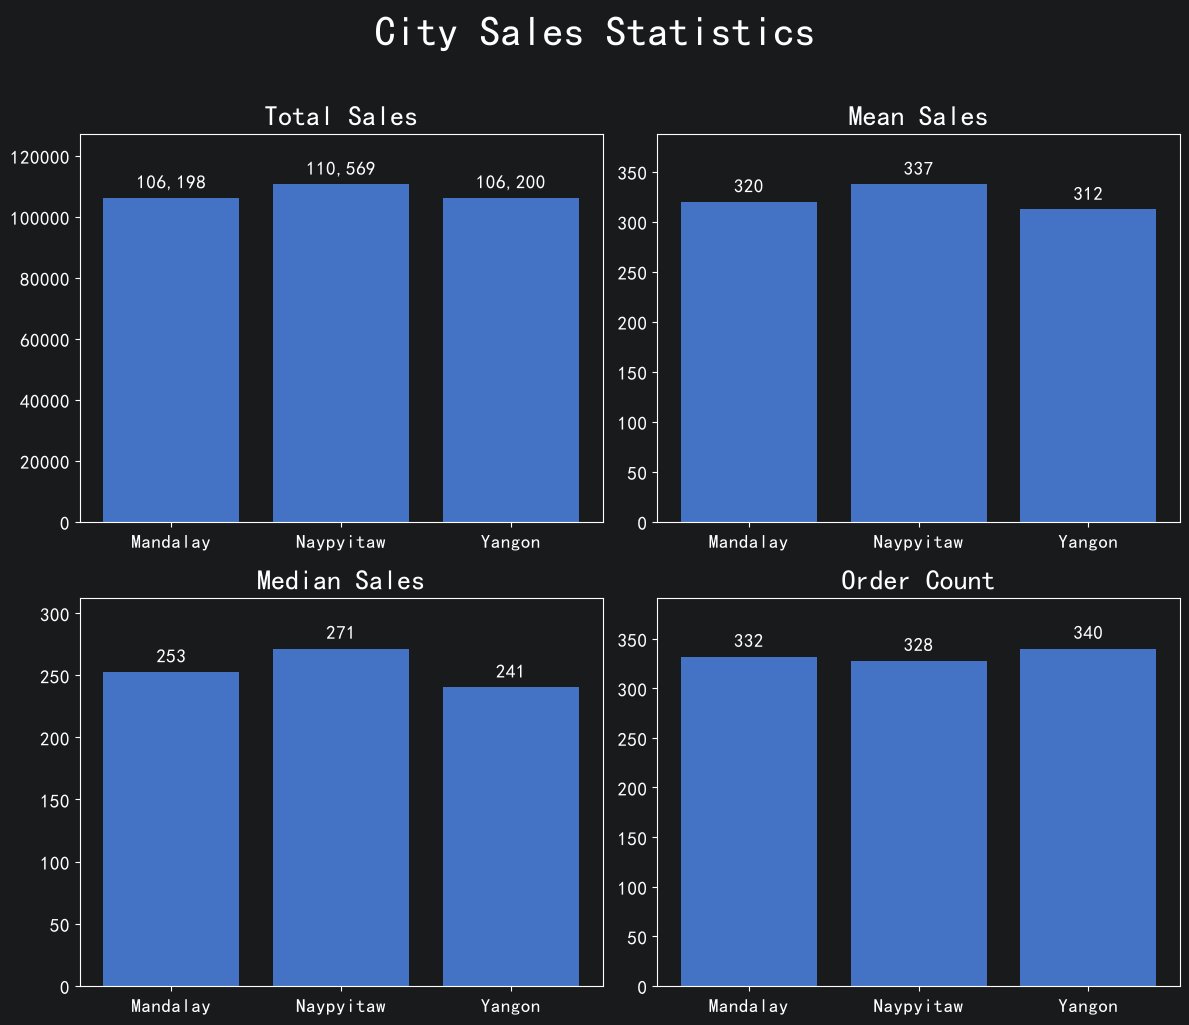

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = [('Sales', 'sum'), ('Sales', 'mean'), ('Sales', 'median'), ('Sales', 'count')]
titles = ['Total Sales', 'Mean Sales', 'Median Sales', 'Order Count']
for ax, metric, title in zip(axes.flat, metrics, titles):
    values = city_stats[metric]
    ax.bar(city_stats['City'], values, color='#4472C4')
    ax.set_title(title, fontsize=20)
    ax.tick_params(axis='both', labelsize=14, colors='white')
    ax.set_ylim(top=max(values) * 1.15)
    for x, y in zip(city_stats['City'], values):
        ax.text(x, y * 1.02, f'{y:,.0f}', ha='center', va='bottom', fontsize=14, color='white')

plt.suptitle('City Sales Statistics', fontsize=30, y=1.02)
plt.tight_layout()
savefig('city_sales')
plt.show()

各城市总体销售额相差不大，Naypyitaw的均值和中位数更高，营业额更高，销量更小，说明该城市客户质量更高

                                       Sales  Quantity
City      Product line                                
Mandalay  Electronic accessories  17051.4435       316
          Fashion accessories     16413.3165       297
          Food and beverages      15214.8885       270
          Health and beauty       19980.6600       320
          Home and lifestyle      17549.1645       295
          Sports and travel       19988.1990       322
Naypyitaw Electronic accessories  18968.9745       333
          Fashion accessories     21560.0700       342
          Food and beverages      23766.8550       369
          Health and beauty       16615.3260       277
          Home and lifestyle      13895.5530       245
          Sports and travel       15761.9280       265
Yangon    Electronic accessories  18317.1135       322
          Fashion accessories     16332.5085       263
          Food and beverages      17163.1005       313
          Health and beauty       12597.7530       257
          

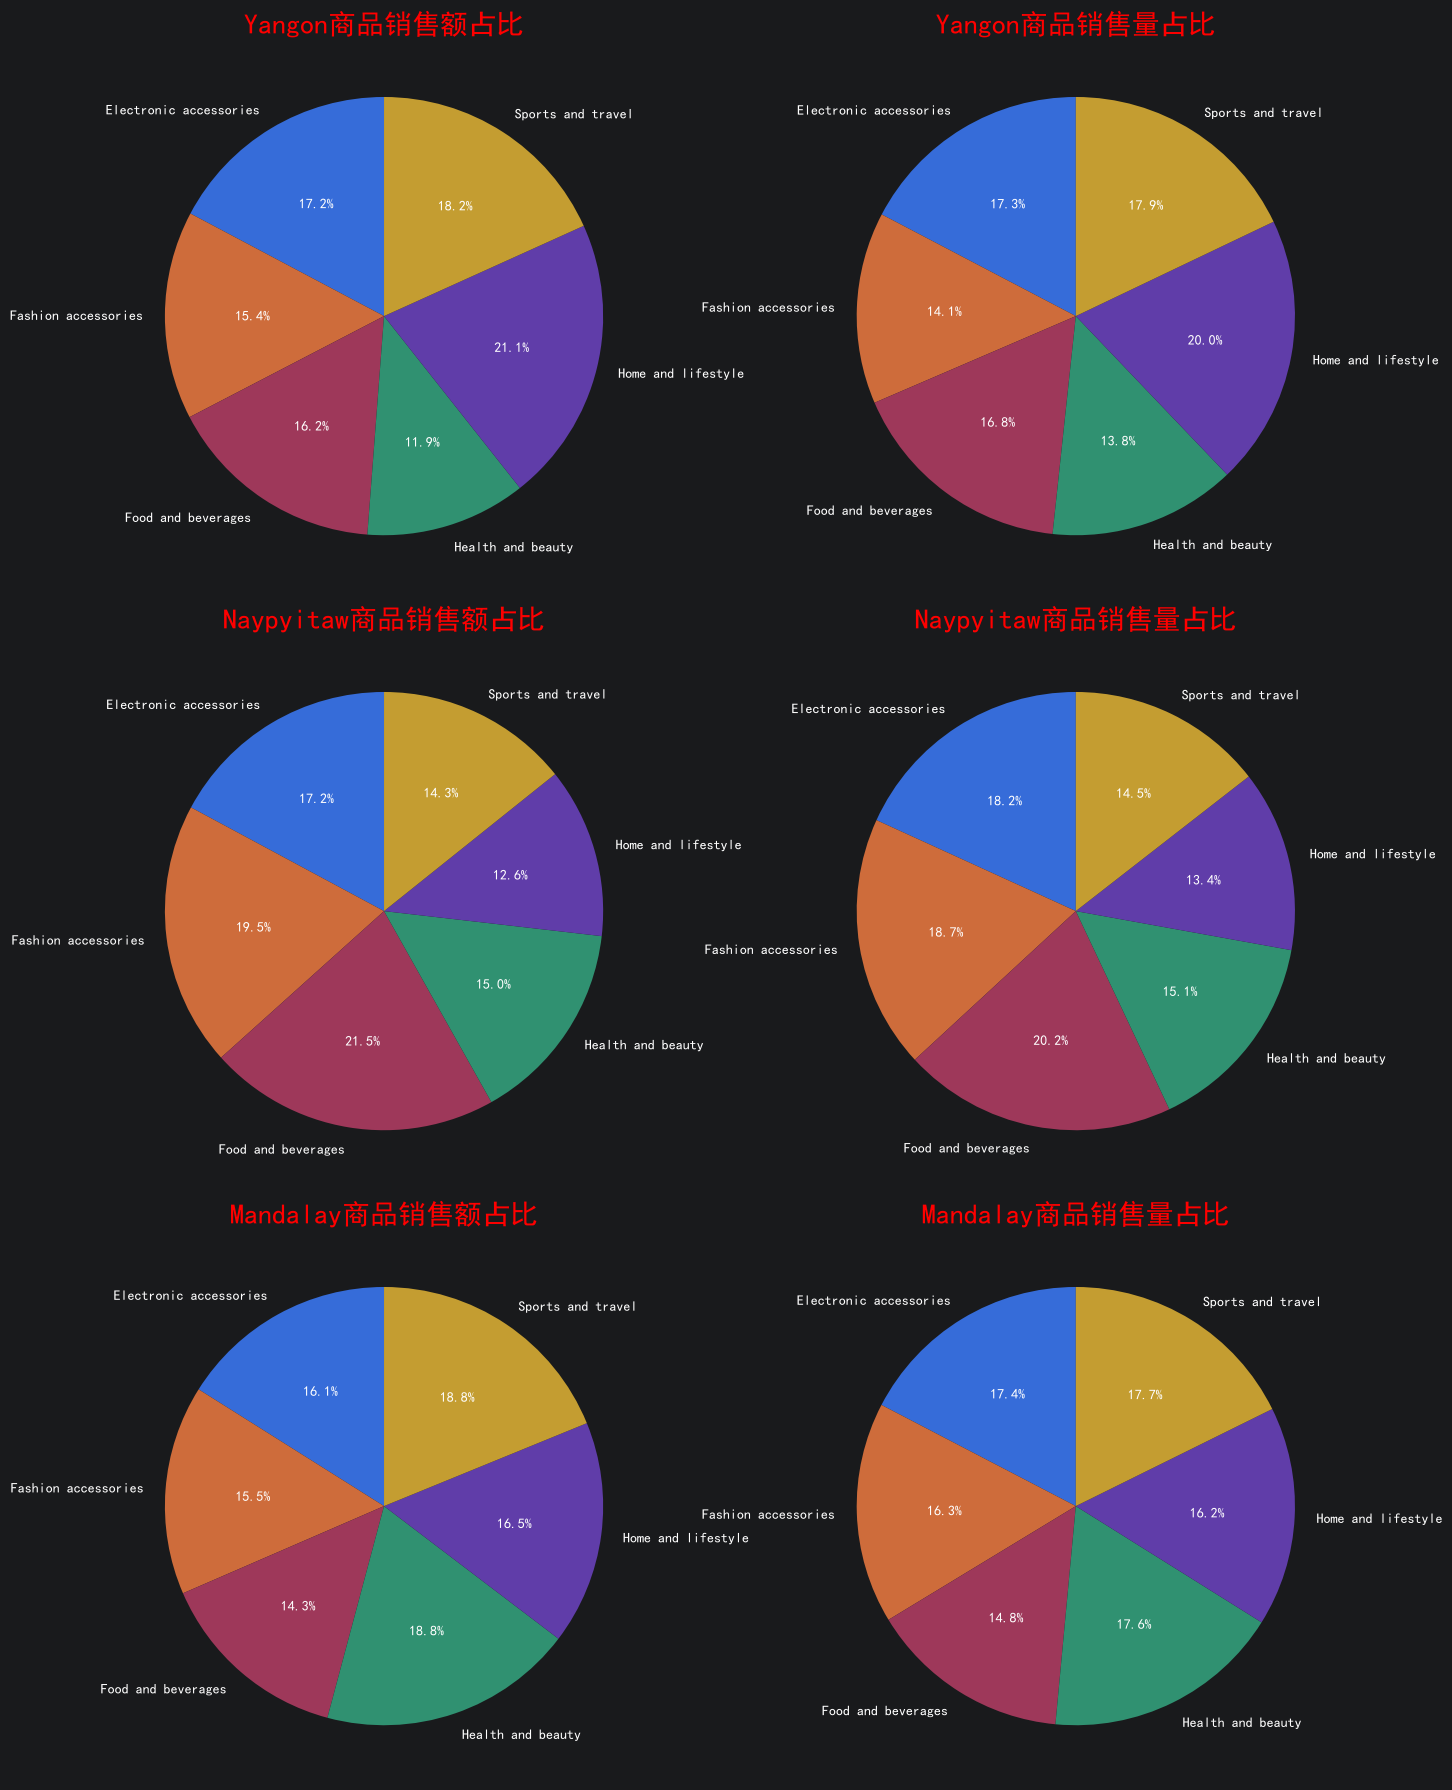

In [75]:
city_product = df.groupby(['City','Product line']).agg({
    'Sales': 'sum',
    'Quantity': 'sum'})

print(city_product)
cities = df['City'].unique()
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
for i, city in enumerate(cities):
    sales_data = city_product.loc[city, 'Sales']
    qty_data = city_product.loc[city, 'Quantity']
    axes[i, 0].pie(sales_data.values,labels = sales_data.index,autopct='%1.1f%%',startangle=90)
    axes[i, 0].set_title(f'{city}商品销售额占比',color='red',fontsize=20)
    axes[i, 1].pie(qty_data.values,labels = qty_data.index,autopct='%1.1f%%',startangle=90)
    axes[i, 1].set_title(f'{city}商品销售量占比',color='red',fontsize=20)
plt.tight_layout()
savefig('city_product_sales')
plt.show()

从销售额占比和销售量占比的差值可以看出，Nay的客户更倾向于购买高净值的的高级食物和时尚产品，低价的电子产品和家居物品。Yan的各品类价格结构非常平均，没有明显溢价品类。Man的健康和运动产品有溢价，但整体比Nay更均衡

Month
2019-01    116291.868
2019-02     97219.374
2019-03    109455.507
Name: Sales, dtype: float64


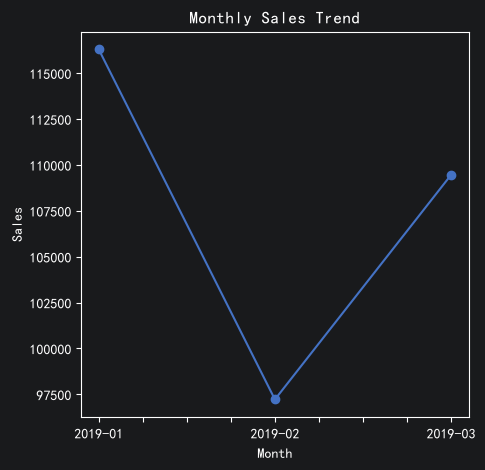

Date
2019-01-31    3751.350581
2019-02-28    3472.120500
2019-03-31    3648.516900
Freq: ME, Name: Sales, dtype: float64


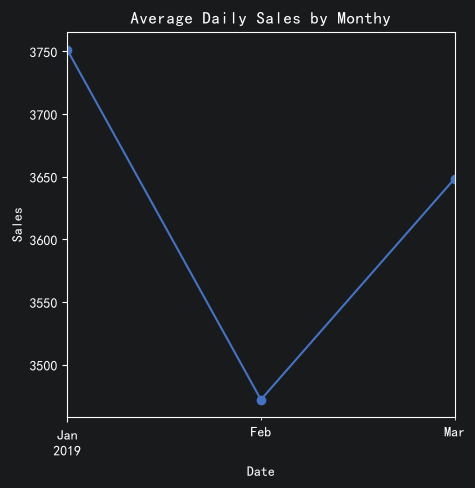

In [76]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)
monthly_sales.plot(figsize=(5, 5), marker='o', color='#4472C4')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
savefig('monthly_sales')
plt.show()
daily_sales = df.set_index('Date')['Sales'].resample('D').sum()
monthly_avg_daily = daily_sales.resample('ME').mean()
print(monthly_avg_daily)
monthly_avg_daily.plot(figsize=(5, 5), marker='o', color='#4472C4')
plt.title('Average Daily Sales by Monthy')
plt.ylabel('Sales')
savefig('monthly_avg_daily')
plt.show()

2月总销售额低于1月和3月但2月自然天数更少，不能仅依据月度总额判断销售情况。
按日均销售额看，2月低于1月和3月说明2月偏弱并不只是天数较少导致，超市可能需要调整经营策略。

Quantity      0.705510
Unit price    0.633962
Rating       -0.036442
Name: Sales, dtype: float64


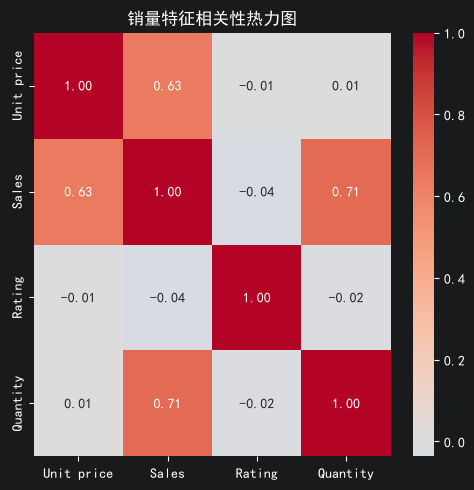

In [77]:
a = df[['Unit price','Sales','Rating','Quantity']].corr()
print(a['Sales'].sort_values(ascending=False)[1:])
plt.figure(figsize = (5,5))
sns.heatmap(a,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('销量特征相关性热力图')
plt.tight_layout()
savefig('correlation_heatmap')
plt.show()

评分与销售额的线性相关性很弱，且单价与销量之间不存在明显的反比关系，单价与销量之间未呈现明显负相关

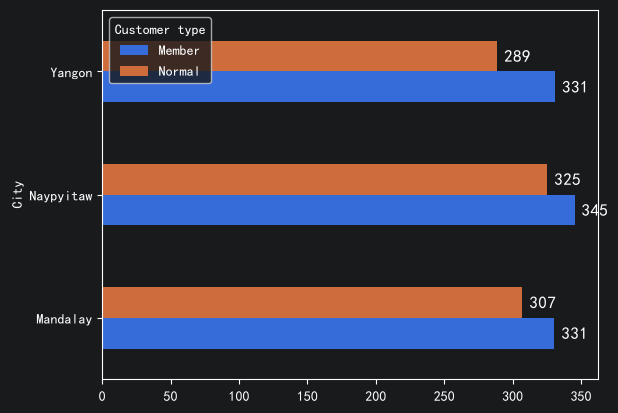

In [78]:
ax = df.groupby(['City', 'Customer type'])['Sales'].mean().unstack().plot(kind='barh')
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f',label_type='edge',fontsize=12,padding=5)
savefig('customer_type_sales')
plt.show()

Nay的高客单价并非主要由会员比例驱动，三城会员客单价差异不大，但Nay的非会员客户客单价更高。这表明Nay市场整体消费水平较高，而非单纯依赖会员体系。Yan的会员溢价效应相对更强，Nay和 Man的会员溢价效应相对较弱。